# Two transaction-sampling options, side by side: BetaBin vs LogitN

Validation notebook for the parallel-track logit-normal pipeline in
[`numerical/logitnormal.py`](../numerical/logitnormal.py) and
[`numerical/numerical_pm_pw.py`](../numerical/numerical_pm_pw.py),
compared against the existing BetaBin/NB pipeline in
[`numerical/distributions.py`](../numerical/distributions.py).

Both options are calibrated to **voluntary** debits (Withdrawal / Transfer /
Card Payment) on the Berka data — the cleanest subset, where account holders
choose how much to spend. The conditional dispersion is the only model knob
that differs between the two:

| option   | $q \mid s$                                | $\mathrm{Var}(q\mid s)$                       | calibrated $\hat\xi/\hat\tau$ (voluntary) |
|----------|--------------------------------------------|-------------------------------------------------|-------------------------------------------|
| BetaBin  | $\mathrm{Beta}(\xi s,\, \xi(1-s))$       | $s(1-s)/(\xi+1)$                                | $\hat\xi = 9.26$                           |
| LogitN   | $\mathrm{LogitN}(\mathrm{logit}\,s,\, \tau^2)$ | $\approx \tau^2[s(1-s)]^2$ (delta method) | $\hat\tau = 0.875$                         |

**Section A** validates the numerical machinery against a synthetic agent-based
simulator calibrated to Berka's $h(s)$. **Section B** compares both options
against the Berka empirical histograms, ending with a data-driven $P(w)$ that
bypasses the $h(s)\propto s^\sigma$ approximation entirely.

Throughout, $w$ is the **outgoing** transaction amount (a debit from the
source account); $m$ is per-account balance.


In [1]:
import os, sys, pathlib
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, betabinom, poisson

from numerical.distributions import (
    compute_params, log_nb_pmf, compute_r_effective,
    Pm_single, Pw_single_local,
)
from numerical.numerical_pm_pw import Pm_single_logitn, Pw_logitn_mc
from numerical.logitnormal import log_pw_cond_pln, log_pm_cond_pln

DATA_DIR = 'berka-dataset'
TX_PATH = os.path.join(DATA_DIR, 'trans-clean-eng.asc')
VOLUNTARY_CATEGS = {'Withdrawal', 'Transfer', 'Card Payment'}

plt.rcParams.update({'figure.dpi': 100, 'axes.labelsize': 12, 'legend.fontsize': 10})

# Berka calibration: voluntary debits (Withdrawal / Transfer / Card Payment).
# Numbers come from dispersion_alternatives.ipynb F2c, F2f and empirical_analysis.ipynb §5.
TAU = 0.875
XI  = 9.26
HS  = dict(sigma=0.0, s_min=0.0367, s_max=0.3367)
print(f"Calibration (voluntary debits):  xi_hat={XI},  tau_hat={TAU}")
print(f"  h(s) = uniform on [{HS['s_min']}, {HS['s_max']}], sigma={HS['sigma']}")

# Each plot cell calls save_fig(name) before plt.show() to also write a vector PDF.
FIG_DIR = pathlib.Path('figs')
FIG_DIR.mkdir(exist_ok=True)
def save_fig(name):
    plt.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')

def histogram(values, num_bins=30, log_bin=False, density=True):
    v = np.asarray(values); v = v[(v > 0) & np.isfinite(v)]
    bins = (np.geomspace(v.min(), v.max(), num_bins+1) if log_bin
            else np.linspace(v.min(), v.max(), num_bins+1))
    counts, edges = np.histogram(v, bins=bins, density=density)
    centers = np.sqrt(edges[:-1] * edges[1:]) if log_bin else 0.5*(edges[:-1]+edges[1:])
    return centers, counts


Calibration (voluntary debits):  xi_hat=9.26,  tau_hat=0.875
  h(s) = uniform on [0.0367, 0.3367], sigma=0.0


## A. Two options head-to-head, calibrated to Berka

### A.1 — Conditional density $p(q \mid s)$

The single point at which the two models differ. Both are calibrated so the
*per-account variance* matches Berka (F2c for BetaBin, F2f for LogitN), but they
prescribe different shapes — Beta is bounded near $s$, LogitN has heavier tails
on both sides.

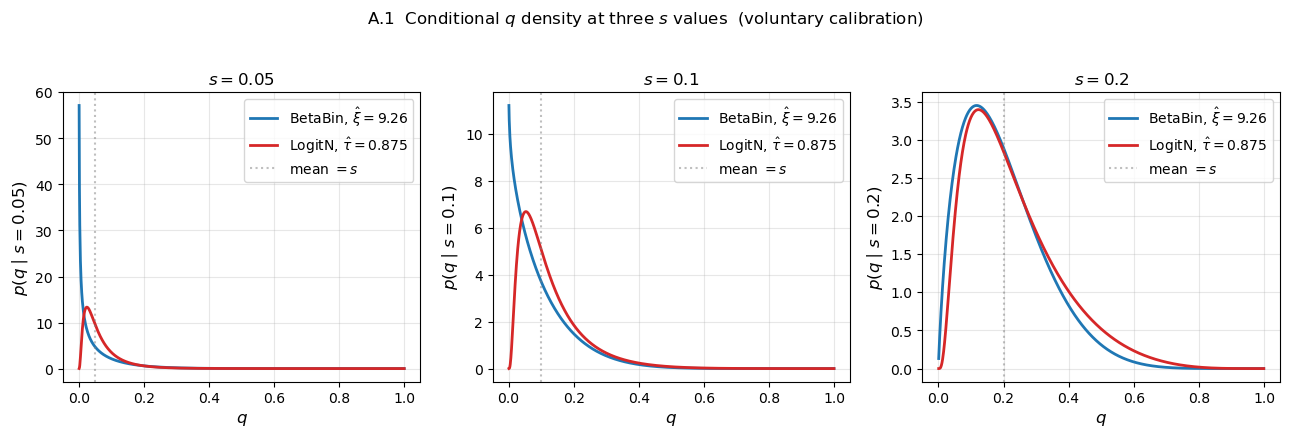

In [2]:
def beta_pdf_q(q, s, xi):
    return beta_dist.pdf(q, xi*s, xi*(1-s))

def logitn_pdf_q(q, s, tau):
    logit_q = np.log(q) - np.log1p(-q)
    logit_s = np.log(s) - np.log1p(-s)
    z = (logit_q - logit_s) / tau
    return np.exp(-0.5*z**2) / (np.sqrt(2*np.pi) * tau * q * (1 - q))

s_vals = [0.05, 0.10, 0.20]
qq = np.linspace(1e-3, 1-1e-3, 1000)
fig, axes = plt.subplots(1, len(s_vals), figsize=(13, 4.2), sharey=False)
for ax, s in zip(axes, s_vals):
    ax.plot(qq, beta_pdf_q(qq, s, XI),    '-', color='C0', lw=2.0,
            label=fr'BetaBin, $\hat\xi={XI}$')
    ax.plot(qq, logitn_pdf_q(qq, s, TAU), '-', color='C3', lw=2.0,
            label=fr'LogitN, $\hat\tau={TAU}$')
    ax.axvline(s, color='gray', ls=':', alpha=0.5, label=r'mean $=s$')
    ax.set_xlabel('$q$'); ax.set_ylabel(rf'$p(q \mid s={s})$')
    ax.set_title(f'$s = {s}$'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('A.1  Conditional $q$ density at three $s$ values  (voluntary calibration)', y=1.03)
plt.tight_layout(); save_fig('a1_q_conditional'); plt.show()


### A.2 — Simulator harness: one run per option

Drive [`src/model.py:transact`](../src/model.py) directly. Both runs use the
same seed/network/h(s); they differ only in the per-transaction sampler. Both
return per-tx amounts and source-balance snapshots.

In [3]:
from src import model

N_SIM   = 500
T_SIM   = 200_000
INIT_BAL = 1_000   # integer-walker units; matches the discrete-Poisson scale of the numerical pmfs

def run_simulation(dispersion_kw, seed=42):
    rng = np.random.default_rng(seed)
    s_per_node = rng.uniform(HS['s_min'], HS['s_max'], size=N_SIM)
    nodes = model.create_nodes(N=N_SIM, activity=1.0, attractivity=1.0,
                               spending=s_per_node.tolist(), mean_iet=1.0, seed=seed)
    trans = model.initialize_transition_matrix(nodes)
    acts  = model.initialize_activations(nodes)
    # decimals=0 -> Decimal balances with no fractional part, so per-tx amounts are integer
    # (the simulator's BetaBinomial/Binomial draws over n=balance walkers). This matches the
    # unit scale of the analytic Poisson/BetaBin pmfs.
    bals  = model.initialize_balances(nodes,
                                      balances=np.full(N_SIM, INIT_BAL),
                                      decimals=0)

    amts = np.empty(T_SIM)
    src_bal_pre = np.empty(T_SIM)
    src_node = np.empty(T_SIM, dtype=int)
    for i in range(T_SIM):
        out = model.transact(nodes, acts, trans, bals, rng=rng, **dispersion_kw)
        amts[i] = float(out['amount'])
        src_bal_pre[i] = float(out['amount']) + float(out['source_bal'])
        src_node[i] = out['source']

    final_bal = np.array([float(bals[k]) for k in range(N_SIM)])
    return dict(s_per_node=s_per_node, amts=amts, src_bal_pre=src_bal_pre,
                src_node=src_node, final_bal=final_bal)

print('Running simulator under BetaBin (xi)...')
sim_bb = run_simulation(dict(s=XI), seed=42)
print('Running simulator under LogitN (tau)...')
sim_ln = run_simulation(dict(dispersion='logitnormal', tau=TAU), seed=42)

for label, sim in [('BetaBin', sim_bb), ('LogitN ', sim_ln)]:
    nz = sim['src_bal_pre'] > 0
    q_emp = sim['amts'][nz] / sim['src_bal_pre'][nz]
    print(f"  {label}: T={T_SIM:,}  mean(q)={q_emp.mean():.4f}  "
          f"mean(w)={sim['amts'].mean():.1f}  "
          f"std(final_bal)={sim['final_bal'].std():.1f}  "
          f"({(~nz).sum()} txns w/ source_bal=0 excluded from q stats)")


Running simulator under BetaBin (xi)...


Running simulator under LogitN (tau)...


  BetaBin: T=200,000  mean(q)=0.1850  mean(w)=136.0  std(final_bal)=930.5  (9 txns w/ source_bal=0 excluded from q stats)
  LogitN : T=200,000  mean(q)=0.2128  mean(w)=168.5  std(final_bal)=784.6  (13 txns w/ source_bal=0 excluded from q stats)


### A.3 — Simulator-emitted $q$ vs target density

Each transaction's $q = w/\mathrm{source\_bal}$ should be a draw from the
chosen conditional. We bin transactions by the source node's $s$ to overlay
the empirical $q$ histogram on the analytic density.

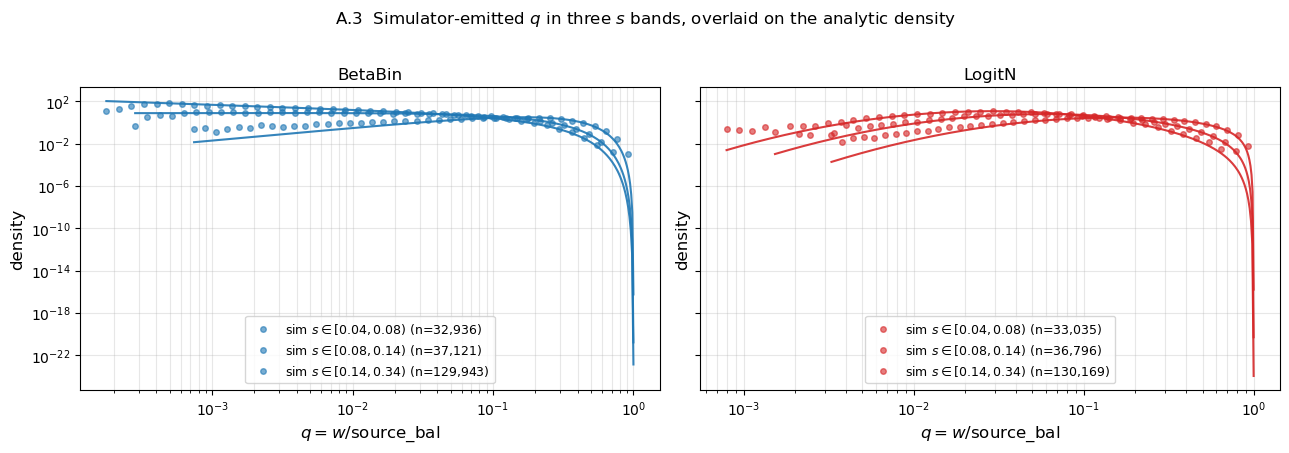

In [4]:
def s_bin_overlay(ax, sim, s_lo, s_hi, kind):
    s_node = sim['s_per_node'][sim['src_node']]
    mask = (s_node >= s_lo) & (s_node < s_hi)
    q_emp = sim['amts'][mask] / sim['src_bal_pre'][mask]
    n = mask.sum()
    if n < 50:
        return
    centers, dens = histogram(q_emp, num_bins=40, log_bin=True)
    s_mid = 0.5*(s_lo + s_hi)
    qq = np.geomspace(centers.min(), 0.999, 400)
    pdf = (beta_pdf_q(qq, s_mid, XI) if kind == 'BetaBin'
           else logitn_pdf_q(qq, s_mid, TAU))
    color = 'C0' if kind == 'BetaBin' else 'C3'
    ax.plot(centers, dens, 'o', color=color, alpha=0.6, ms=4,
            label=f'sim $s\in[{s_lo:.2f},{s_hi:.2f})$ (n={n:,})')
    ax.plot(qq, pdf, '-', color=color, lw=1.5, alpha=0.9)

s_edges = [HS['s_min'], 0.08, 0.14, HS['s_max']]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, kind, sim in zip(axes, ['BetaBin', 'LogitN'], [sim_bb, sim_ln]):
    for s_lo, s_hi in zip(s_edges[:-1], s_edges[1:]):
        s_bin_overlay(ax, sim, s_lo, s_hi, kind)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$q = w/\mathrm{source\_bal}$'); ax.set_ylabel('density')
    ax.set_title(kind); ax.legend(loc='lower center', fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
plt.suptitle('A.3  Simulator-emitted $q$ in three $s$ bands, overlaid on the analytic density',
             y=1.02)
plt.tight_layout(); save_fig('a3_q_simulator'); plt.show()


### A.4 — Per-node occupancy $p(m\mid s)$

Conditional balance distribution at a fixed spending rate $s$. Numerical:
- BetaBin gives $\mathrm{NB}(r_\mathrm{eff}(s),\, p(s))$ (companion §B.2 of the SM).
- LogitN gives the Poisson-LogitNormal compound from
  [`log_pm_cond_pln`](../numerical/logitnormal.py).

Simulator: bin nodes by their assigned $s$, take final-balance snapshots.

compute_params: K0=135.35, mean_m=1000.0, s_mean=0.1867, s_inv_mean=7.39


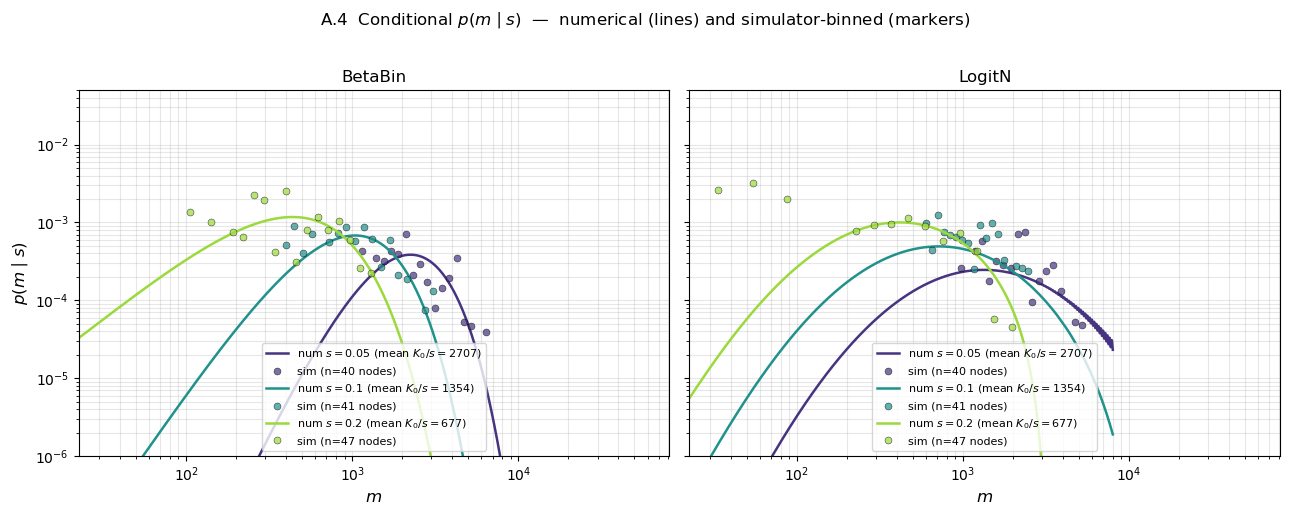

In [5]:
params = compute_params(sigma=HS['sigma'], s_min=HS['s_min'], s_max=HS['s_max'],
                        N=N_SIM, M=int(N_SIM * INIT_BAL))
K0 = params['K0']; s_mean = params['s_mean']
print(f"compute_params: K0={K0:.2f}, mean_m={params['mean_m']:.1f}, "
      f"s_mean={s_mean:.4f}, s_inv_mean={params['s_inv_mean']:.2f}")

s_targets = [0.05, 0.10, 0.20]
band = 0.015
s_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(s_targets)))
m_grid = np.arange(0, int(8*INIT_BAL))

def num_pm_betabin(m, s):
    lam = K0 / s
    r_eff = compute_r_effective(s, s_mean, XI)
    p = r_eff / (r_eff + lam)
    return np.exp(np.array([log_nb_pmf(int(mi), r_eff, p) for mi in m]))

def num_pm_logitn(m, s):
    lam = K0 / s
    return np.exp(np.array([log_pm_cond_pln(int(mi), lam, s, TAU) for mi in m]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)
for ax, kind, sim, num_fn in [
    (axes[0], 'BetaBin', sim_bb, num_pm_betabin),
    (axes[1], 'LogitN',  sim_ln, num_pm_logitn),
]:
    for s_t, col in zip(s_targets, s_colors):
        # numerical curve at this s
        ax.plot(m_grid, num_fn(m_grid, s_t), '-', color=col, lw=1.8,
                label=fr'num $s={s_t}$ (mean $K_0/s={K0/s_t:.0f}$)')
        # simulator-binned histogram at this s
        mask = np.abs(sim['s_per_node'] - s_t) < band
        if mask.sum() > 0:
            c, d = histogram(sim['final_bal'][mask], num_bins=18, log_bin=True)
            ax.plot(c, d, 'o', color=col, alpha=0.7, ms=5, mec='k', mew=0.4,
                    label=f'sim (n={mask.sum()} nodes)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(K0 / max(s_targets) / 30, K0 / min(s_targets) * 30)
    ax.set_ylim(1e-6, 5e-2)
    ax.set_xlabel('$m$'); ax.set_title(kind)
    ax.legend(fontsize=8, loc='lower center'); ax.grid(True, alpha=0.3, which='both')
axes[0].set_ylabel(r'$p(m \mid s)$')
plt.suptitle(r'A.4  Conditional $p(m \mid s)$  —  numerical (lines) and simulator-binned (markers)', y=1.02)
plt.tight_layout(); save_fig('a4_pm_conditional'); plt.show()


### A.5 — Marginal $P(m)$

Integrate $p(m\mid s)$ over $h(s)$. Simulator: histogram of final balances
over all nodes.

Computing numerical P(m) for both options...


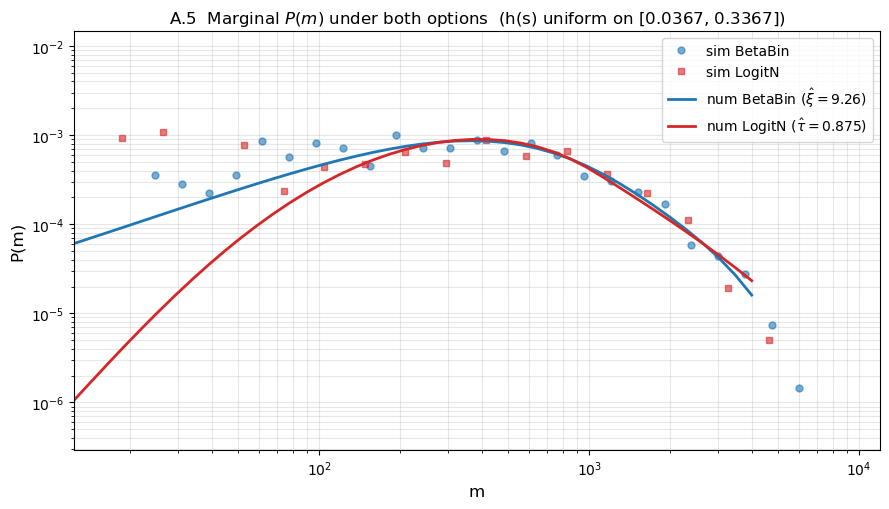

In [6]:
m_grid_eval = np.unique(np.round(np.geomspace(1, 4*INIT_BAL, 60)).astype(int))

print('Computing numerical P(m) for both options...')
P_bb = np.array([Pm_single(int(m), params, model='nb', xi=XI, n_s=2000) for m in m_grid_eval])
P_ln = np.array([Pm_single_logitn(int(m), params, tau=TAU, n_s=2000)    for m in m_grid_eval])

c_sim_bb, d_sim_bb = histogram(sim_bb['final_bal'], num_bins=25, log_bin=True)
c_sim_ln, d_sim_ln = histogram(sim_ln['final_bal'], num_bins=25, log_bin=True)

fig, ax = plt.subplots(1, 1, figsize=(9, 5.2))
ax.plot(c_sim_bb, d_sim_bb, 'o', color='C0', alpha=0.6, ms=5, label='sim BetaBin')
ax.plot(c_sim_ln, d_sim_ln, 's', color='C3', alpha=0.6, ms=5, label='sim LogitN')
ax.plot(m_grid_eval, P_bb, '-', color='C0', lw=2.0, label=fr'num BetaBin ($\hat\xi={XI}$)')
ax.plot(m_grid_eval, P_ln, '-', color='C3', lw=2.0, label=fr'num LogitN ($\hat\tau={TAU}$)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(c_sim_bb.min()*0.5, c_sim_bb.max()*2)
ax.set_ylim(min(d_sim_bb[d_sim_bb>0].min(), d_sim_ln[d_sim_ln>0].min())*0.2,
            max(d_sim_bb.max(), d_sim_ln.max())*3)
ax.set_xlabel('m'); ax.set_ylabel('P(m)')
ax.set_title(fr'A.5  Marginal $P(m)$ under both options  (h(s) uniform on [{HS["s_min"]}, {HS["s_max"]}])')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); save_fig('a5_pm_marginal'); plt.show()


### A.6 — Per-tx pmf $p(w\mid M, s)$

Conditional transaction-size pmf at fixed balance scale and spending rate.
- BetaBin: $w\mid M, s \sim \mathrm{BetaBin}(M, \xi s, \xi(1-s))$ — integer pmf.
- LogitN: $w\mid M, s \sim$ Poisson-LogitNormal at rate $Mq$,
  $q\sim\mathrm{LogitN}(\mathrm{logit}\,s,\,\tau^2)$.

Simulator: per-tx amount $w$ from each option (no binning needed since we fix
both the balance scale via $M=\mathrm{INIT\_BAL}$ — the simulator's mean
balance is conserved at $\mathrm{INIT\_BAL}$ — and the spending rate via the
$s$-band).

s = 0.1±0.015, source_bal in [850, 1150]:  BetaBin n=3,239,  LogitN n=3,241


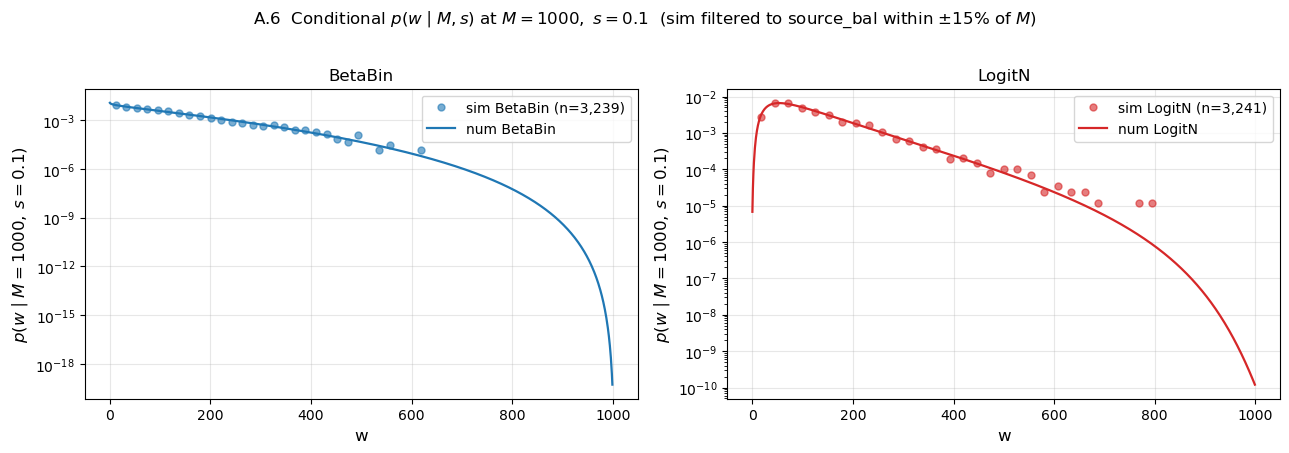

In [7]:
s_target = 0.10
s_band = 0.015
M_eg = INIT_BAL
bal_band = 0.15      # source_bal_pre within ±15% of M for clean fixed-M comparison
w_grid = np.arange(0, int(M_eg))

# Numerical conditional pmfs at fixed (M, s)
P_w_bb_pmf = betabinom.pmf(w_grid, int(M_eg), XI*s_target, XI*(1-s_target))
P_w_ln_pmf = np.exp([log_pw_cond_pln(int(w), M_eg, s_target, TAU) for w in w_grid])

# Simulator: bin transactions whose source has s in band AND source_bal near M
def sim_w_bin(sim, s_lo, s_hi, M, bal_band):
    s_node = sim['s_per_node'][sim['src_node']]
    src_bal = sim['src_bal_pre']
    mask = ((s_node >= s_lo) & (s_node < s_hi)
            & (src_bal >= M*(1-bal_band)) & (src_bal <= M*(1+bal_band)))
    return sim['amts'][mask]

w_bb = sim_w_bin(sim_bb, s_target - s_band, s_target + s_band, M_eg, bal_band)
w_ln = sim_w_bin(sim_ln, s_target - s_band, s_target + s_band, M_eg, bal_band)
print(f's = {s_target}±{s_band}, source_bal in [{M_eg*(1-bal_band):.0f}, {M_eg*(1+bal_band):.0f}]:'
      f'  BetaBin n={len(w_bb):,},  LogitN n={len(w_ln):,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, kind, w_sim, P_pmf, color in [
    (axes[0], 'BetaBin', w_bb, P_w_bb_pmf, 'C0'),
    (axes[1], 'LogitN',  w_ln, P_w_ln_pmf, 'C3'),
]:
    if len(w_sim) > 0:
        c, d = histogram(w_sim, num_bins=30, log_bin=False)
        ax.plot(c, d, 'o', color=color, alpha=0.6, ms=5,
                label=f'sim {kind} (n={len(w_sim):,})')
    ax.plot(w_grid, P_pmf, '-', color=color, lw=1.6, label=f'num {kind}')
    ax.set_xlabel('w')
    ax.set_ylabel(rf'$p(w \mid M={int(M_eg)},\, s={s_target})$')
    ax.set_title(kind); ax.set_yscale('log')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(rf'A.6  Conditional $p(w \mid M, s)$ at $M={int(M_eg)},\ s={s_target}$  '
             rf'(sim filtered to source_bal within $\pm{int(100*bal_band)}\%$ of $M$)',
             y=1.02)
plt.tight_layout(); save_fig('a6_pw_conditional'); plt.show()


### A.7 — Marginal $P(w)$

The SM compounding (eq. 624):
$$P(w) \;=\; \sum_m \int_s p(w \mid m, s)\, p(m \mid s)\, h(s)\, ds$$

For BetaBin this admits the closed-form Poisson-Gamma-Beta integral
[`Pw_single_local`](../numerical/distributions.py) (SM eq. 43). For LogitN
the same chain has no clean closed form, so [`Pw_logitn_mc`](../numerical/numerical_pm_pw.py)
evaluates it by Monte Carlo over $(s, q, m, q', w)$. Both should track the
simulator within MC noise.

Computing P(w) BetaBin via Pw_single_local at xi=9.26...


Computing P(w) LogitN via Pw_logitn_mc at tau=0.875...


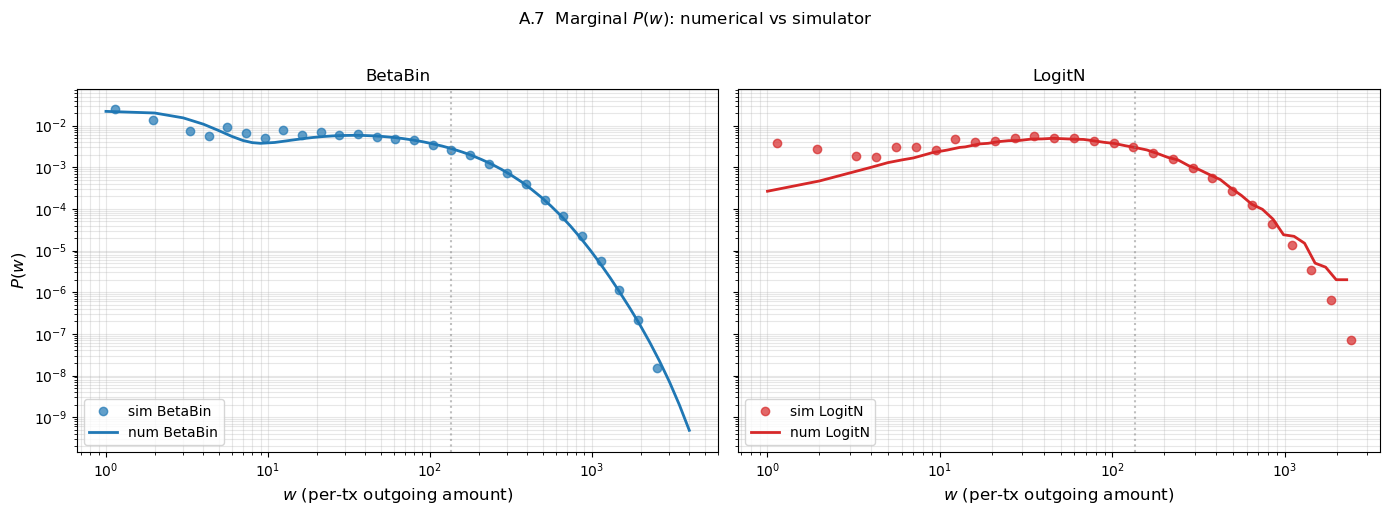

In [8]:
w_grid_eval = np.unique(np.round(np.geomspace(1, 4*INIT_BAL, 60)).astype(int))

print(f'Computing P(w) BetaBin via Pw_single_local at xi={XI}...')
P_w_bb = np.array([Pw_single_local(int(w), params, xi=XI) for w in w_grid_eval])
print(f'Computing P(w) LogitN via Pw_logitn_mc at tau={TAU}...')
P_w_ln = Pw_logitn_mc(w_grid_eval, params, tau=TAU, n_mc=1_000_000, seed=2026)

c_w_bb, d_w_bb = histogram(sim_bb['amts'], num_bins=30, log_bin=True)
c_w_ln, d_w_ln = histogram(sim_ln['amts'], num_bins=30, log_bin=True)
mask_bb = P_w_bb > 0
mask_ln = P_w_ln > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharey=True)
for ax, kind, c_sim, d_sim, P_num, mask, color in [
    (axes[0], 'BetaBin', c_w_bb, d_w_bb, P_w_bb, mask_bb, 'C0'),
    (axes[1], 'LogitN',  c_w_ln, d_w_ln, P_w_ln, mask_ln, 'C3'),
]:
    ax.plot(c_sim, d_sim, 'o', color=color, alpha=0.7, ms=6, label=f'sim {kind}')
    ax.plot(w_grid_eval[mask], P_num[mask], '-', color=color, lw=2.0,
            label=f'num {kind}')
    ax.axvline(K0, color='gray', ls=':', alpha=0.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('$w$ (per-tx outgoing amount)')
    ax.set_title(kind); ax.legend(loc='lower left'); ax.grid(True, alpha=0.3, which='both')
axes[0].set_ylabel('$P(w)$')
ymin = min(d_w_bb[d_w_bb>0].min(), d_w_ln[d_w_ln>0].min(),
           P_w_bb[P_w_bb>0].min() if (P_w_bb>0).any() else 1e-12,
           P_w_ln[P_w_ln>0].min() if (P_w_ln>0).any() else 1e-12) * 0.3
ymax = max(d_w_bb.max(), d_w_ln.max()) * 3
for ax in axes:
    ax.set_ylim(max(ymin, 1e-12), ymax)
plt.suptitle(r'A.7  Marginal $P(w)$: numerical vs simulator', y=1.02)
plt.tight_layout(); save_fig('a7_pw_marginal'); plt.show()


---

## B. Berka empirical comparison

Now bring in actual Berka data. The same $\hat\xi, \hat\tau$ from F2c/F2f
are the only model knobs.

In [9]:
tx = pd.read_csv(
    TX_PATH, sep=';',
    dtype={'trans_id': 'int64', 'account_id': 'int32', 'date': 'string',
           'type': 'category', 'amount': 'float64', 'balance': 'float64',
           'bank': 'string', 'account': 'string', 'value': 'float64',
           'categ': 'category', 'detail': 'string'},
)
tx['date'] = pd.to_datetime(tx['date'], format='%y%m%d')
tx = tx.sort_values(['account_id', 'date', 'trans_id']).reset_index(drop=True)
tx['pre_balance'] = tx['balance'] - tx['value']

is_debit = tx['type'].eq('DEBIT')
tx['frac_out'] = np.where(is_debit & (tx['pre_balance'] > 0),
                          tx['amount'] / tx['pre_balance'], np.nan)
tx['voluntary'] = is_debit & tx['categ'].isin(VOLUNTARY_CATEGS)
tx.loc[tx['frac_out'] > 1, 'frac_out'] = np.nan

agents = pd.DataFrame({
    'mean_frac_out_all':       tx.groupby('account_id', observed=True)['frac_out'].mean(),
    'mean_frac_out_voluntary': tx['frac_out'].where(tx['voluntary']).groupby(tx['account_id'], observed=True).mean(),
    'mean_bal':                tx.groupby('account_id', observed=True)['balance'].mean(),
    'tx_out':                  is_debit.astype(int).groupby(tx['account_id'], observed=True).sum(),
})
print(f'Loaded: {len(tx):,} txns across {tx.account_id.nunique():,} accounts')


Loaded: 1,056,320 txns across 4,500 accounts


### Setup for §B: Berka-scale `params` and simulator re-run

Re-run the simulator with `init_bal = params_berka['mean_m']` so each panel
below can show simulator + numerical + Berka empirical on a shared axis. The
§A simulator at INIT_BAL=1000 was for unit-scale agreement with the analytic
pmfs; here we want Berka units (~$2{\times}10^4$ Kč mean balance per node).

In [10]:
# Berka-scale params
N_BERKA = 4_427
TOTAL_BAL_BERKA = 90_806_052
params_berka = compute_params(sigma=HS['sigma'], s_min=HS['s_min'], s_max=HS['s_max'],
                              N=N_BERKA, M=TOTAL_BAL_BERKA)
print(f"Berka params: K0={params_berka['K0']:.1f}, mean_m={params_berka['mean_m']:.0f}")

# Re-run simulator at Berka scale so its histograms can sit on the same axes as the
# Berka empirical and the numerical curves.
INIT_BAL_BERKA = int(params_berka['mean_m'])

def run_simulation_at_scale(init_bal, dispersion_kw, seed=42):
    rng = np.random.default_rng(seed)
    s_per_node = rng.uniform(HS['s_min'], HS['s_max'], size=N_SIM)
    nodes = model.create_nodes(N=N_SIM, activity=1.0, attractivity=1.0,
                               spending=s_per_node.tolist(), mean_iet=1.0, seed=seed)
    trans = model.initialize_transition_matrix(nodes)
    acts  = model.initialize_activations(nodes)
    bals  = model.initialize_balances(nodes,
                                      balances=np.full(N_SIM, init_bal),
                                      decimals=0)
    amts = np.empty(T_SIM)
    for i in range(T_SIM):
        out = model.transact(nodes, acts, trans, bals, rng=rng, **dispersion_kw)
        amts[i] = float(out['amount'])
    final_bal = np.array([float(bals[k]) for k in range(N_SIM)])
    return dict(amts=amts, final_bal=final_bal)

print(f'Re-running simulator at Berka scale (init_bal={INIT_BAL_BERKA:,})...')
sim_bb_b = run_simulation_at_scale(INIT_BAL_BERKA, dict(s=XI), seed=42)
sim_ln_b = run_simulation_at_scale(INIT_BAL_BERKA, dict(dispersion='logitnormal', tau=TAU), seed=42)
print(f"  BetaBin: mean(w)={sim_bb_b['amts'].mean():,.0f}, mean(m)={sim_bb_b['final_bal'].mean():,.0f}")
print(f"  LogitN : mean(w)={sim_ln_b['amts'].mean():,.0f}, mean(m)={sim_ln_b['final_bal'].mean():,.0f}")


Berka params: K0=2776.4, mean_m=20512
Re-running simulator at Berka scale (init_bal=20,511)...


  BetaBin: mean(w)=2,797, mean(m)=20,511
  LogitN : mean(w)=3,435, mean(m)=20,511


### B.1 — Empirical $P(m)$ vs simulator and numerical, by family

Two panels: BetaBin (left) and LogitN (right). Each shows the Berka empirical
per-account mean balance, the simulator's final-balance histogram at Berka
scale, and the analytic $P(m)$ curve under that family.

Computing numerical P(m) BetaBin and LogitN at Berka scale...


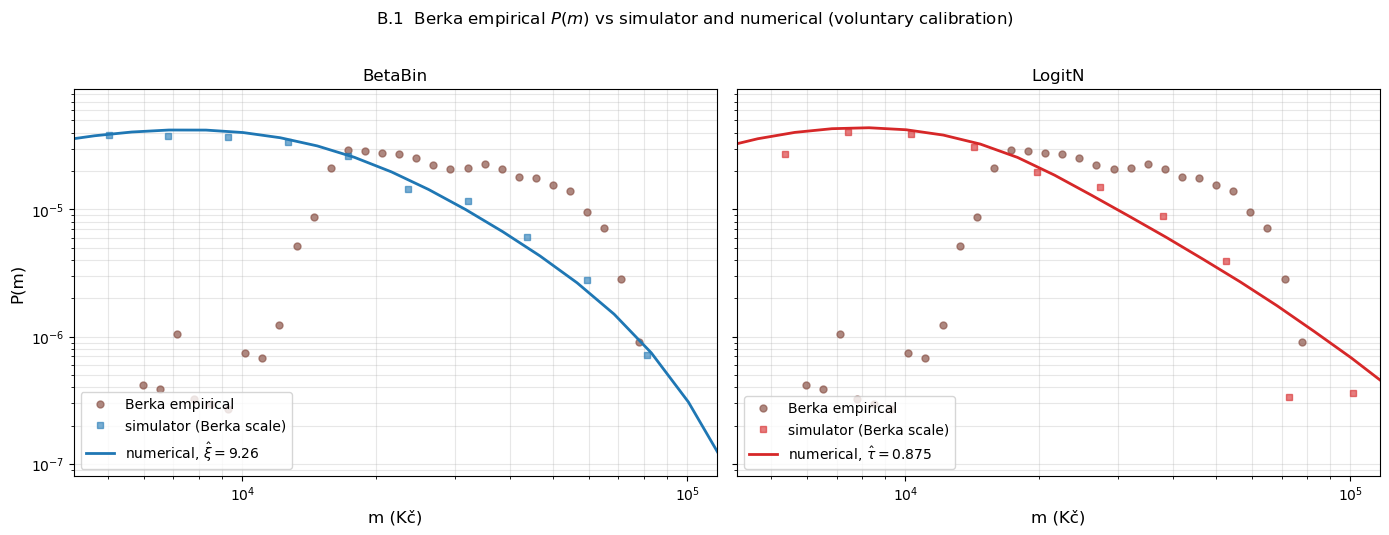

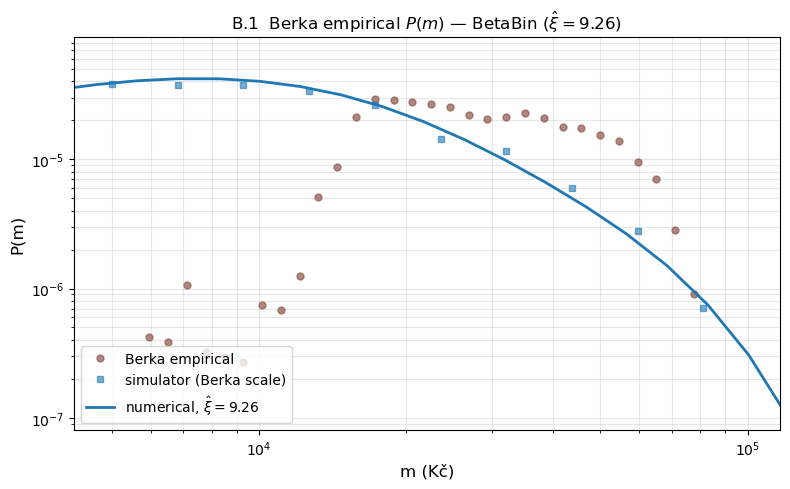

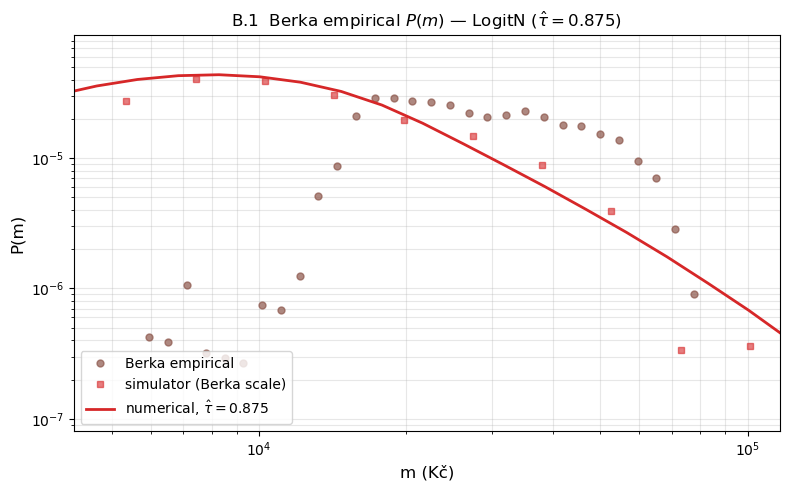

In [11]:
emp_m = agents['mean_bal'].dropna(); emp_m = emp_m[emp_m > 0]
m_centers, m_dens = histogram(emp_m, num_bins=30, log_bin=True)
m_grid_b = np.unique(np.round(np.geomspace(10, emp_m.max()*1.5, 50)).astype(int))

print('Computing numerical P(m) BetaBin and LogitN at Berka scale...')
P_m_bb_b = np.array([Pm_single(int(m), params_berka, model='nb', xi=XI, n_s=2000) for m in m_grid_b])
P_m_ln_b = np.array([Pm_single_logitn(int(m), params_berka, tau=TAU, n_s=2000)    for m in m_grid_b])

c_sim_m_bb, d_sim_m_bb = histogram(sim_bb_b['final_bal'], num_bins=20, log_bin=True)
c_sim_m_ln, d_sim_m_ln = histogram(sim_ln_b['final_bal'], num_bins=20, log_bin=True)

m_xlim = (m_centers.min()*0.7, m_centers.max()*1.5)
m_ylim = (max(m_dens.min(), 1e-9) * 0.3, m_dens.max() * 3)

# Two-panel side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, kind, P_num, c_sim, d_sim, color, param_label in [
    (axes[0], 'BetaBin', P_m_bb_b, c_sim_m_bb, d_sim_m_bb, 'C0', fr'$\hat\xi={XI}$'),
    (axes[1], 'LogitN',  P_m_ln_b, c_sim_m_ln, d_sim_m_ln, 'C3', fr'$\hat\tau={TAU}$'),
]:
    ax.plot(m_centers, m_dens, 'o', color='C5', alpha=0.7, ms=5, label='Berka empirical')
    ax.plot(c_sim, d_sim, 's', color=color, alpha=0.6, ms=5, label='simulator (Berka scale)')
    ax.plot(m_grid_b, P_num, '-', color=color, lw=2.0, label=f'numerical, {param_label}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(*m_xlim); ax.set_ylim(*m_ylim)
    ax.set_xlabel('m (Kč)'); ax.set_title(kind)
    ax.legend(loc='lower left'); ax.grid(True, alpha=0.3, which='both')
axes[0].set_ylabel('P(m)')
plt.suptitle('B.1  Berka empirical $P(m)$ vs simulator and numerical (voluntary calibration)', y=1.02)
plt.tight_layout(); save_fig('b1_pm_berka'); plt.show()

# Single-panel alternates — same data, one family at a time, for slides
def _b1_single_panel(kind, P_num, c_sim, d_sim, color, param_label, fig_name):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5.0))
    ax.plot(m_centers, m_dens, 'o', color='C5', alpha=0.7, ms=5, label='Berka empirical')
    ax.plot(c_sim, d_sim, 's', color=color, alpha=0.6, ms=5, label='simulator (Berka scale)')
    ax.plot(m_grid_b, P_num, '-', color=color, lw=2.0, label=f'numerical, {param_label}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(*m_xlim); ax.set_ylim(*m_ylim)
    ax.set_xlabel('m (Kč)'); ax.set_ylabel('P(m)')
    ax.set_title(f'B.1  Berka empirical $P(m)$ — {kind} ({param_label})')
    ax.legend(loc='lower left'); ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout(); save_fig(fig_name); plt.show()

_b1_single_panel('BetaBin', P_m_bb_b, c_sim_m_bb, d_sim_m_bb, 'C0',
                 fr'$\hat\xi={XI}$', 'b1_pm_berka_betabin')
_b1_single_panel('LogitN',  P_m_ln_b, c_sim_m_ln, d_sim_m_ln, 'C3',
                 fr'$\hat\tau={TAU}$', 'b1_pm_berka_logitn')


### B.2 — Empirical $P(w)$ vs simulator and numerical, by family

Two panels, same structure as B.1 but for the per-tx outgoing amount.
Each shows the Berka voluntary-debit histogram, the Berka-scale simulator's
amount histogram, and the analytic $P(w)$ via SM compounding:
- **BetaBin** via `Pw_single_local(xi=`$\hat\xi$`)` — SM eq. 43 closed form.
- **LogitN** via `Pw_logitn_mc(tau=`$\hat\tau$`)` — Monte-Carlo SM compounding.

The $h(s) \propto s^\sigma$ approximation enters the numerical curves; B.3
strips it out by using the empirical $(s_i, m_i)$ joint directly.

Empirical P(w): 493,828 voluntary debit transactions
Computing Berka-scale P(w) BetaBin via Pw_single_local...


Computing Berka-scale P(w) LogitN via Pw_logitn_mc...


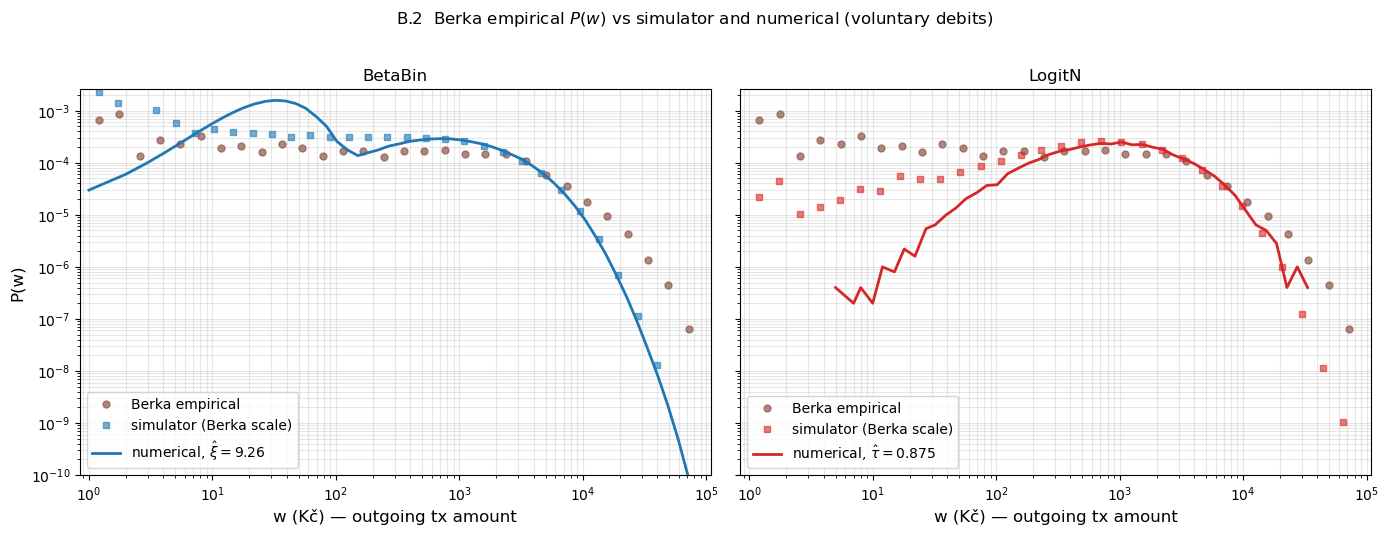

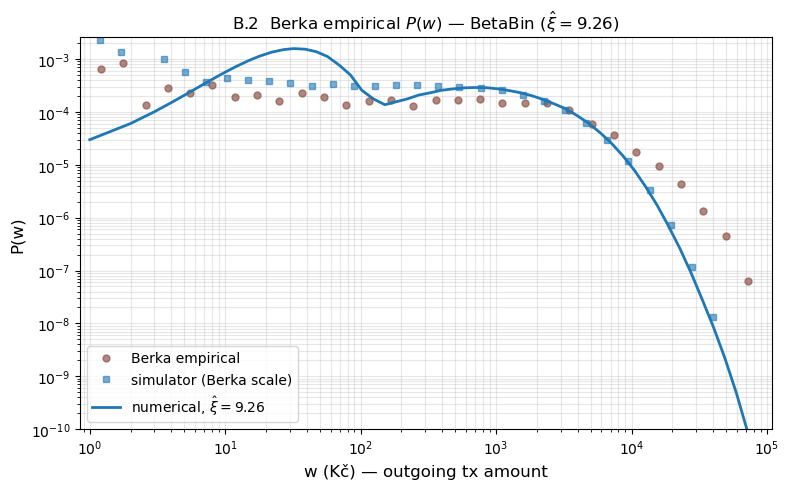

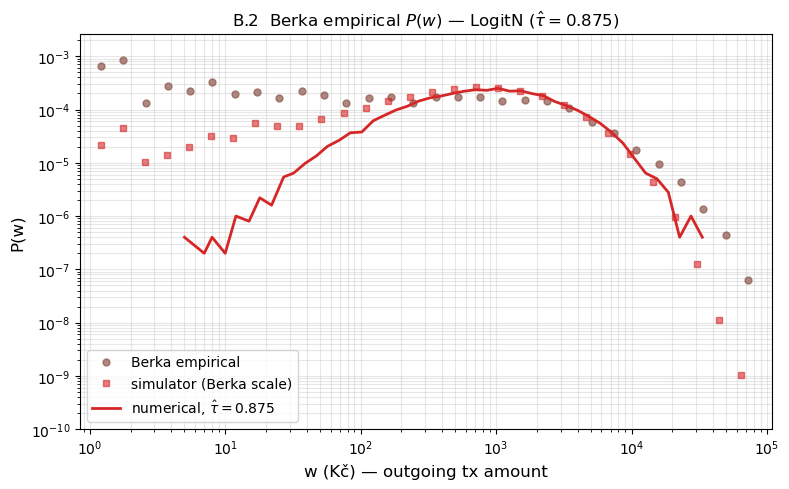

In [12]:
emp_w = tx.loc[tx['voluntary'], 'amount']   # voluntary debits — outgoing tx amount
emp_w = emp_w[emp_w > 0]
print(f'Empirical P(w): {len(emp_w):,} voluntary debit transactions')

w_centers_b, w_dens_b = histogram(emp_w, num_bins=30, log_bin=True)
w_grid_b = np.unique(np.round(np.geomspace(1, emp_w.max(), 60)).astype(int))

print('Computing Berka-scale P(w) BetaBin via Pw_single_local...')
P_w_bb_b = np.array([Pw_single_local(int(w), params_berka, xi=XI) for w in w_grid_b])
print('Computing Berka-scale P(w) LogitN via Pw_logitn_mc...')
P_w_ln_b = Pw_logitn_mc(w_grid_b, params_berka, tau=TAU, n_mc=5_000_000, seed=2026)

# Simulator histograms at Berka scale
c_sim_w_bb, d_sim_w_bb = histogram(sim_bb_b['amts'], num_bins=30, log_bin=True)
c_sim_w_ln, d_sim_w_ln = histogram(sim_ln_b['amts'], num_bins=30, log_bin=True)

# Mask zero-pmf entries from MC output so they don't draw cliff-spikes on log-y
mask_bb = P_w_bb_b > 0
mask_ln = P_w_ln_b > 0

w_xlim = (w_centers_b.min()*0.7, w_centers_b.max()*1.5)
w_ymin = min([d[d>0].min() for d in [w_dens_b, P_w_bb_b, P_w_ln_b, d_sim_w_bb, d_sim_w_ln]
              if (d>0).any()]) * 0.3
w_ymax = w_dens_b.max() * 3
w_ylim = (max(w_ymin, 1e-10), w_ymax)

# Two-panel side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, kind, P_num, mask, c_sim, d_sim, color, param_label in [
    (axes[0], 'BetaBin', P_w_bb_b, mask_bb, c_sim_w_bb, d_sim_w_bb, 'C0', fr'$\hat\xi={XI}$'),
    (axes[1], 'LogitN',  P_w_ln_b, mask_ln, c_sim_w_ln, d_sim_w_ln, 'C3', fr'$\hat\tau={TAU}$'),
]:
    ax.plot(w_centers_b, w_dens_b, 'o', color='C5', alpha=0.7, ms=5, label='Berka empirical')
    ax.plot(c_sim, d_sim, 's', color=color, alpha=0.6, ms=5, label='simulator (Berka scale)')
    ax.plot(w_grid_b[mask], P_num[mask], '-', color=color, lw=2.0,
            label=f'numerical, {param_label}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(*w_xlim); ax.set_ylim(*w_ylim)
    ax.set_xlabel('w (Kč) — outgoing tx amount'); ax.set_title(kind)
    ax.legend(loc='lower left'); ax.grid(True, alpha=0.3, which='both')
axes[0].set_ylabel('P(w)')
plt.suptitle('B.2  Berka empirical $P(w)$ vs simulator and numerical (voluntary debits)', y=1.02)
plt.tight_layout(); save_fig('b2_pw_berka'); plt.show()

# Single-panel alternates — same data, one family at a time, for slides
def _b2_single_panel(kind, P_num, mask, c_sim, d_sim, color, param_label, fig_name):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5.0))
    ax.plot(w_centers_b, w_dens_b, 'o', color='C5', alpha=0.7, ms=5, label='Berka empirical')
    ax.plot(c_sim, d_sim, 's', color=color, alpha=0.6, ms=5, label='simulator (Berka scale)')
    ax.plot(w_grid_b[mask], P_num[mask], '-', color=color, lw=2.0,
            label=f'numerical, {param_label}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(*w_xlim); ax.set_ylim(*w_ylim)
    ax.set_xlabel('w (Kč) — outgoing tx amount'); ax.set_ylabel('P(w)')
    ax.set_title(f'B.2  Berka empirical $P(w)$ — {kind} ({param_label})')
    ax.legend(loc='lower left'); ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout(); save_fig(fig_name); plt.show()

_b2_single_panel('BetaBin', P_w_bb_b, mask_bb, c_sim_w_bb, d_sim_w_bb, 'C0',
                 fr'$\hat\xi={XI}$', 'b2_pw_berka_betabin')
_b2_single_panel('LogitN',  P_w_ln_b, mask_ln, c_sim_w_ln, d_sim_w_ln, 'C3',
                 fr'$\hat\tau={TAU}$', 'b2_pw_berka_logitn')


### B.3 — Data-driven $P(w)$: bootstrap from empirical $(m, s)$

The cleanest possible test of the dispersion choice: for *each* Berka
debit transaction, look up the *empirical* $(s_i, m_i)$ for that account, draw
$q$ from the candidate conditional, set $w = q\cdot m_i$, and compare the
synthetic distribution to the empirical $P(w)$.

This bypasses $h(s)\propto s^\sigma$ entirely — the empirical $(s, m)$ joint
*is* the distribution. It also weights tx by the per-account activity
automatically (each tx contributes one draw). The dispersion choice is the
only model knob.

B.3  bootstrap base: 493,828 voluntary tx with valid (s, m)


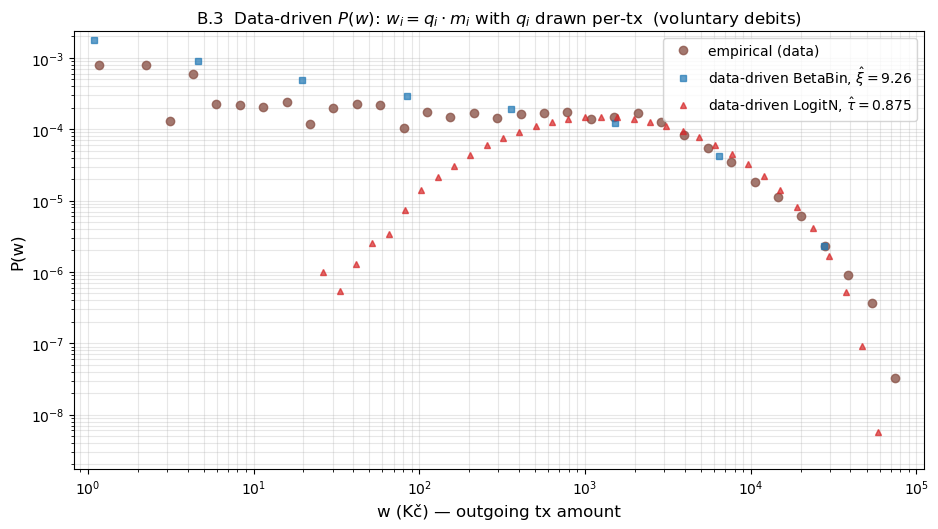


  median(w):  empirical=3,300  BetaBin=3,495  LogitN=4,364
  mean(w):    empirical=6,131  BetaBin=5,422  LogitN=6,484


In [13]:
# Per-tx (s_i, m_i) using account-level voluntary spending propensity and time-mean balance
sb = tx.loc[tx['voluntary'], ['account_id', 'amount']].merge(
    agents[['mean_frac_out_voluntary', 'mean_bal']],
    left_on='account_id', right_index=True, how='left',
)
ok = (sb['mean_bal'] > 0) & sb['mean_frac_out_voluntary'].between(1e-4, 0.999, inclusive='neither')
sb = sb.loc[ok].reset_index(drop=True)
print(f'B.3  bootstrap base: {len(sb):,} voluntary tx with valid (s, m)')

s_arr = sb['mean_frac_out_voluntary'].to_numpy()
m_arr = sb['mean_bal'].to_numpy()
w_emp = sb['amount'].to_numpy()

rng = np.random.default_rng(2026)

# BetaBin: q ~ Beta(xi*s, xi*(1-s)),  w = q*m
q_bb = rng.beta(XI * s_arr, XI * (1 - s_arr))
w_bb_pred = q_bb * m_arr

# LogitN: logit q = logit s + tau*z,  w = q*m
z = rng.standard_normal(len(s_arr))
q_ln = 1 / (1 + np.exp(-(np.log(s_arr/(1-s_arr)) + TAU * z)))
w_ln_pred = q_ln * m_arr

c_emp,    d_emp    = histogram(w_emp,      num_bins=35, log_bin=True)
c_bb_pr,  d_bb_pr  = histogram(w_bb_pred,  num_bins=35, log_bin=True)
c_ln_pr,  d_ln_pr  = histogram(w_ln_pred,  num_bins=35, log_bin=True)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5.4))
ax.plot(c_emp,   d_emp,   'o', color='C5', alpha=0.8, ms=6, label='empirical (data)')
ax.plot(c_bb_pr, d_bb_pr, 's', color='C0', alpha=0.7, ms=5,
        label=fr'data-driven BetaBin, $\hat\xi={XI}$')
ax.plot(c_ln_pr, d_ln_pr, '^', color='C3', alpha=0.7, ms=5,
        label=fr'data-driven LogitN, $\hat\tau={TAU}$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(c_emp.min()*0.7, c_emp.max()*1.5)
pos_mins = [a[a>0].min() for a in [d_emp, d_bb_pr, d_ln_pr] if (a>0).any()]
ax.set_ylim(max(min(pos_mins), 1e-12) * 0.3, d_emp.max() * 3)
ax.set_xlabel('w (Kč) — outgoing tx amount'); ax.set_ylabel('P(w)')
ax.set_title(r'B.3  Data-driven $P(w)$: $w_i = q_i \cdot m_i$ with $q_i$ drawn per-tx  (voluntary debits)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); save_fig('b3_pw_data_driven'); plt.show()

# Summary statistics
print(f'\n  median(w):  empirical={np.median(w_emp):,.0f}  '
      f'BetaBin={np.median(w_bb_pred):,.0f}  '
      f'LogitN={np.median(w_ln_pred):,.0f}')
print(f'  mean(w):    empirical={np.mean(w_emp):,.0f}  '
      f'BetaBin={np.mean(w_bb_pred):,.0f}  '
      f'LogitN={np.mean(w_ln_pred):,.0f}')


## Notes

**Section A** validates that both numerical pipelines (BetaBin/NB and Poisson-LogitN)
agree with the agent-based simulator under the same calibration. The conditional
$p(w \mid M, s)$ in A.6 is the cleanest test (sim filtered to source_bal $\approx M$
makes the fixed-$M$ comparison apples-to-apples).

**Section B** compares both options against Berka voluntary debits.
B.1/B.2 use the $h(s) \propto s^\sigma$ approximation (uniform on
$[s_{\min}^{p01}, s_{\max}^{p99}]$, $\sigma=0$) — so any mismatch is partly
the dispersion choice and partly the $h(s)$ approximation. B.3 bypasses
$h(s)$ by drawing per-tx $q$ from the conditional and applying it to the
*empirical* $(s_i, m_i)$ — the cleanest dispersion-only test.

**Throughout**: $w$ is the outgoing per-tx amount (a debit from the source);
$m$ is per-account balance.

**Deferred** (companion §8.5–8.6): saddle-point derivation of the new tail
exponent for $P(m)$, replacement section for SM §B.2/§C.
